# Lens parameter distributions (SIE)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ler.lens_galaxy_population import LensGalaxyParameterDistribution

In [2]:
ler_sie = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="sie_galaxy",
    directory="../interpolator_json",
)


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ../interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ../interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ../interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : rayleigh
rayleigh interpolator will be loaded from ../interpolator_json/axis_ratio/rayleigh_2.json
using ler availabl

In [3]:
# stronly lensed 
lens_params = ler_sie.sample_lens_parameters(50000)

sampling lens parameters with epl_shear_sl_parameters_rvs...


In [4]:
lens_params.keys()

dict_keys(['zl', 'zs', 'sigma', 'theta_E', 'q', 'phi', 'gamma', 'gamma1', 'gamma2', 'mass_1_source', 'mass_ratio', 'mass_2_source', 'geocent_time', 'ra', 'dec', 'phase', 'psi', 'theta_jn', 'luminosity_distance', 'mass_1', 'mass_2'])

- gamma = 2
- gamma1 = 0
- gamma2 = 0

In [5]:
# sample intrinsic parameters
lens_params_int = ler_sie.sample_all_routine_epl_shear_intrinsic(50000)


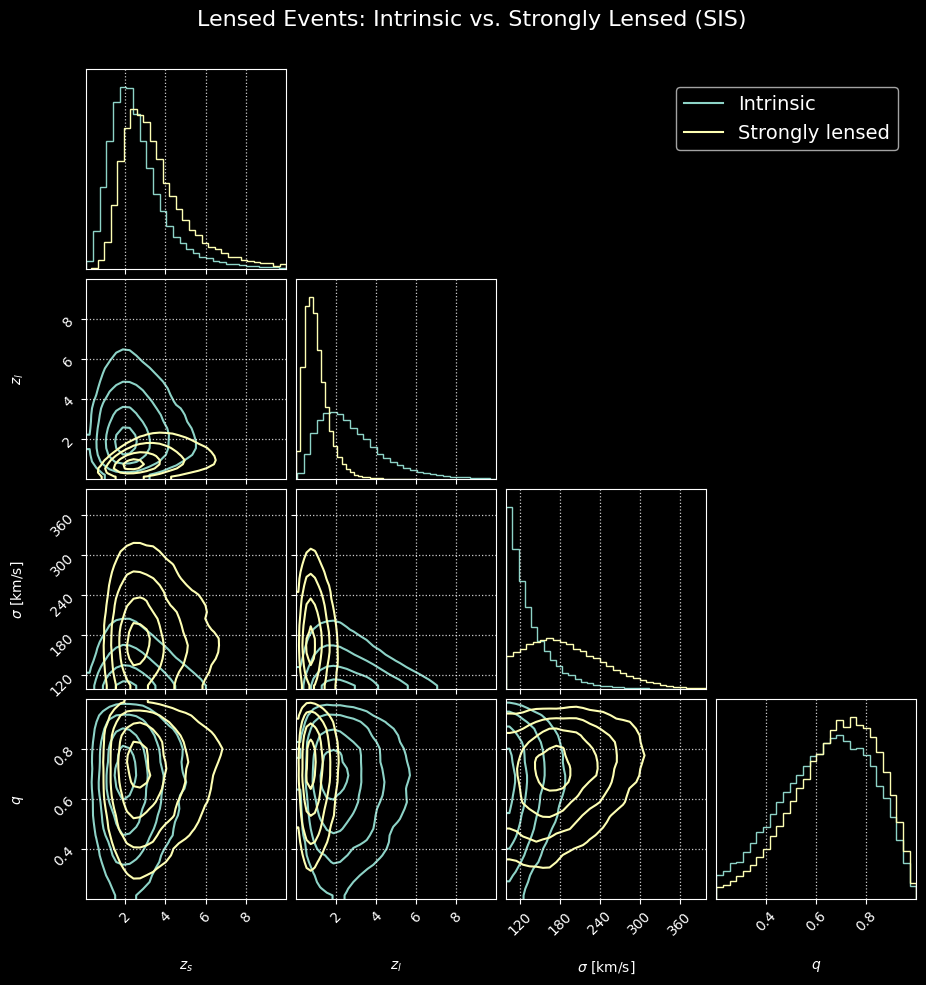

In [8]:
import corner
import matplotlib.lines as mlines

# Load data
param = lens_params
param_intrinsic = lens_params_int

# Lensing-specific parameters to compare
param_names = ['zs', 'zl', 'sigma', 'q']
labels = ['$z_s$', '$z_l$', r'$\sigma$ [km/s]', '$q$']

# Prepare data for corner plot
samples_intrinsic = np.stack([param_intrinsic[p] for p in param_names], axis=1)
samples_all = np.stack([param[p] for p in param_names], axis=1)

fig = corner.corner(
    samples_intrinsic, 
    labels=labels, 
    color='C0', 
    alpha=0.5,
    bins=30,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True}
)

corner.corner(
    samples_all, 
    labels=labels, 
    color='C1', 
    alpha=0.5,
    bins=30,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True},
    fig=fig,
)

# Add grid lines
for ax in fig.axes:
    ax.set_axisbelow(False)

    ax.grid(
        True,
        which='major',
        linestyle=':',
        linewidth=0.9,
        alpha=0.8,
        zorder=10,
    )

# Add legend
green_line = mlines.Line2D([], [], color='C0', label='Intrinsic')
blue_line = mlines.Line2D([], [], color='C1', label='Strongly lensed')
leg = fig.legend(
    handles=[green_line, blue_line],
    loc='upper right',
    bbox_to_anchor=(0.95, 0.95),
    fontsize=14,
)

fig.suptitle(
    'Lensed Events: Intrinsic vs. Strongly Lensed (SIS)',
    fontsize=16,
    y=1.02,
)

plt.show()

## Compare with SIS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ler.lens_galaxy_population import LensGalaxyParameterDistribution

ler_sie = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="sie_galaxy",
    directory="../interpolator_json",
)

ler_sis = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="sis_galaxy",
    directory="../interpolator_json",
)


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ../interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ../interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ../interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : rayleigh
rayleigh interpolator will be loaded from ../interpolator_json/axis_ratio/rayleigh_2.json
using ler availabl

In [2]:
# stronly lensed 
lens_params_sie = ler_sie.sample_lens_parameters(50000)
lens_params_sis = ler_sis.sample_lens_parameters(50000)

sampling lens parameters with epl_shear_sl_parameters_rvs...
sampling lens parameters with epl_shear_sl_parameters_rvs...


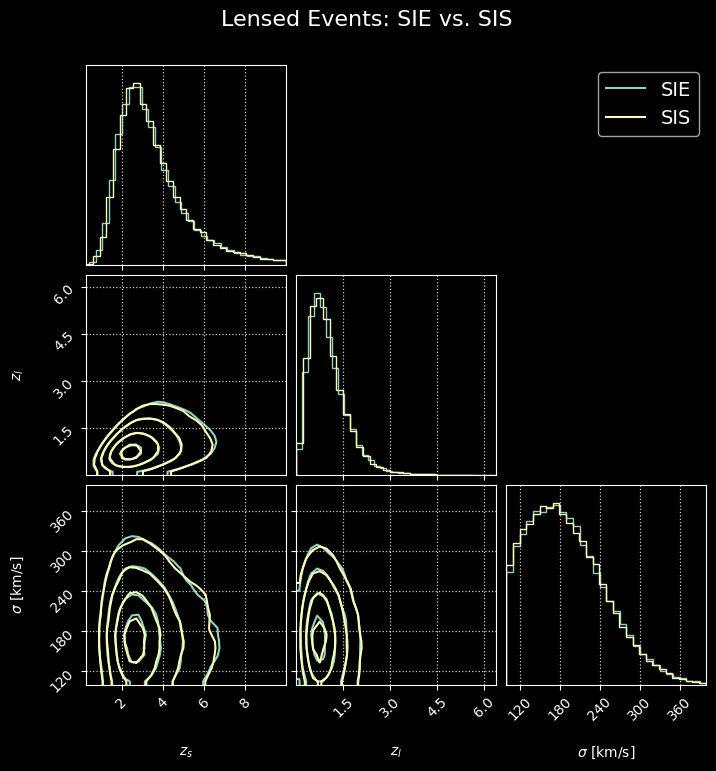

In [6]:
import corner
import matplotlib.lines as mlines

# Lensing-specific parameters to compare
param_names = ['zs', 'zl', 'sigma']
labels = ['$z_s$', '$z_l$', r'$\sigma$ [km/s]']

# Prepare data for corner plot
samples_sie = np.stack([lens_params_sie[p] for p in param_names], axis=1)
samples_sis = np.stack([lens_params_sis[p] for p in param_names], axis=1)

fig = corner.corner(
    samples_sie, 
    labels=labels, 
    color='C0', 
    alpha=0.5,
    bins=30,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True}
)

corner.corner(
    samples_sis, 
    labels=labels, 
    color='C1', 
    alpha=0.5,
    bins=30,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True},
    fig=fig,
)

# Add grid lines
for ax in fig.axes:
    ax.set_axisbelow(False)

    ax.grid(
        True,
        which='major',
        linestyle=':',
        linewidth=0.9,
        alpha=0.8,
        zorder=10,
    )

# Add legend
green_line = mlines.Line2D([], [], color='C0', label='SIE')
blue_line = mlines.Line2D([], [], color='C1', label='SIS')
leg = fig.legend(
    handles=[green_line, blue_line],
    loc='upper right',
    bbox_to_anchor=(0.95, 0.95),
    fontsize=14,
)

fig.suptitle(
    'Lensed Events: SIE vs. SIS',
    fontsize=16,
    y=1.02,
)

plt.show()

## Compare optical depths

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)
from ler.lens_galaxy_population import LensGalaxyParameterDistribution

In [4]:
create_new = False
ler_analytical_cs = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="sie_galaxy",
    directory="../interpolator_json",
    lens_functions = dict(
        cross_section="cross_section_sie_feixu",
    ),
    lens_priors = dict(
        velocity_dispersion="velocity_dispersion_choi",
        lens_redshift_sl="lens_redshift_strongly_lensed_numerical",
    ),
    lens_priors_params = dict(
        velocity_dispersion=dict(
            param_name="velocity_dispersion",
            sampler_type="velocity_dispersion_choi",
            sigma_min=1.0,
            sigma_max=600.0,
            alpha=2.32,
            beta=2.67,
            phistar=8.0e-3 * cosmo.h**3,
            sigmastar=161.0,
        ),
        lens_redshift_sl=dict(
            param_name = "lens_redshift_sl",
            sampler_type = "lens_redshift_strongly_lensed_numerical",
            lens_type = "sie_galaxy",
            integration_size=50000,
            use_multiprocessing=False,
            cross_section_epl_shear_interpolation=False,
        ),
    ),
    create_new_interpolator = dict(
        lens_redshift_sl=dict(
            create_new=create_new, resolution=16, zl_resolution=48, cdf_size=400
        ),
        # lens_redshift=dict(
        #     create_new=create_new, resolution=16, zl_resolution=48, cdf_size=400
        # ),
        optical_depth=dict(create_new=create_new, resolution=16, cdf_size=500),
    )
)
# time 


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ../interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ../interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_choi
velocity_dispersion_choi interpolator will be loaded from ../interpolator_json/velocity_dispersion/velocity_dispersion_choi_3.json
using ler available axis_ratio function : rayleigh
rayleigh interpolator will be loaded from ../interpolator_json/axis_ratio/rayleigh_3.json
using ler available a

In [5]:
create_new = False
ler_interpolation_cs = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="sie_galaxy",
    directory="../interpolator_json",
    lens_functions = dict(
        cross_section="cross_section_epl_shear_njit",
    ),
    lens_functions_params = dict(
        cross_section=dict(
            num_th=500, maginf=-10000.0
        ),
    ),  
    lens_priors = dict(
        velocity_dispersion="velocity_dispersion_choi",
        lens_redshift_sl="lens_redshift_strongly_lensed_numerical",
    ),
    lens_priors_params = dict(
        velocity_dispersion=dict(
            param_name="velocity_dispersion",
            sampler_type="velocity_dispersion_choi",
            sigma_min=1.0,
            sigma_max=600.0,
            alpha=2.32,
            beta=2.67,
            phistar=8.0e-3 * cosmo.h**3,
            sigmastar=161.0,
        ),
        lens_redshift_sl=dict(
            param_name = "lens_redshift_sl",
            sampler_type = "lens_redshift_strongly_lensed_numerical",
            lens_type = "sie_galaxy",
            integration_size=50000,
            use_multiprocessing=False,
            cross_section_epl_shear_interpolation=True,
        ),
    ),
    create_new_interpolator = dict(
        lens_redshift_sl=dict(
            create_new=create_new, resolution=16, zl_resolution=48, cdf_size=400
        ),
        # lens_redshift=dict(
        #     create_new=create_new, resolution=16, zl_resolution=48, cdf_size=400
        # ),
        optical_depth=dict(create_new=create_new, resolution=16, cdf_size=500),
    )
)
# time : 21.3


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ../interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ../interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_choi
velocity_dispersion_choi interpolator will be loaded from ../interpolator_json/velocity_dispersion/velocity_dispersion_choi_3.json
using ler available axis_ratio function : rayleigh
rayleigh interpolator will be loaded from ../interpolator_json/axis_ratio/rayleigh_3.json
using ler available a

optical_depth_sis_analytic interpolator will be loaded from ../interpolator_json/optical_depth/optical_depth_sis_analytic_4.json


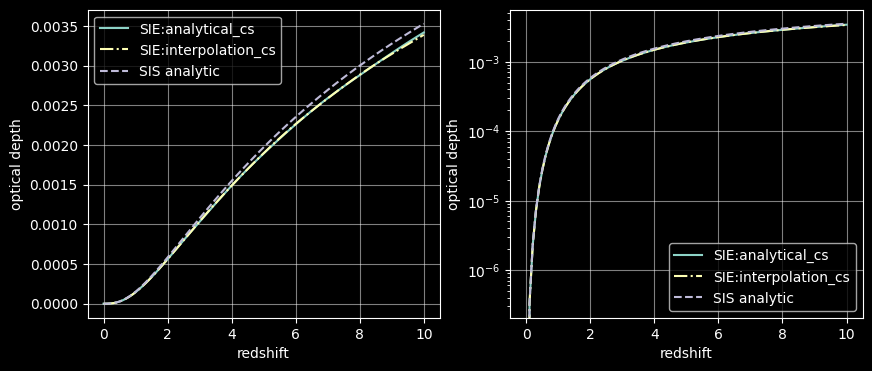

In [9]:
import numpy as np
import matplotlib.pyplot as plt

zs = np.linspace(0.001, 10, 100)
tau_analytical_cs = ler_analytical_cs.optical_depth(zs)
# tau_numerical_cs = ler_numerical_cs.optical_depth(zs)
tau_interpolation_cs = ler_interpolation_cs.optical_depth(zs)
tau_sis_haris = ler_analytical_cs.optical_depth_sis_analytic(zs)

# linear scale on the left and log scale on the right
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot linear scale on the left
ax1.plot(zs, tau_analytical_cs, '-', color='C0', label='SIE:analytical_cs')
# ax1.plot(zs, tau_numerical_cs, '--', label='numerical_cs')
ax1.plot(zs, tau_interpolation_cs, '-.', color='C1', label='SIE:interpolation_cs')
ax1.plot(zs, tau_sis_haris, '--', color='C2', label='SIS analytic')

ax1.set_xlabel('redshift')
ax1.set_ylabel('optical depth')
ax1.set_yscale('linear')
ax1.legend()
ax1.grid(alpha=0.5)

# Plot log scale on the right
ax2.plot(zs, tau_analytical_cs, '-', color='C0', label='SIE:analytical_cs')
# ax2.plot(zs, tau_numerical_cs, '--', label='numerical_cs')
ax2.plot(zs, tau_interpolation_cs, '-.', color='C1', label='SIE:interpolation_cs')
ax2.plot(zs, tau_sis_haris, '--', color='C2', label='SIS analytic')

ax2.set_xlabel('redshift')
ax2.set_ylabel('optical depth')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(alpha=0.5)

plt.show()